![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    Flux Processing Chain (here starting Level-4.1)
</b>
</br>
  
</span>
<p>Post-processing of EddyPro <i>_fluxnet_</i> output files</p>

---
**Notebook version**: `11.0` (19 Nov 2025)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

In [1]:
import pickle
from datetime import datetime
from diive.core.io.files import save_parquet, load_parquet

</br>

# Load previous `fpc` instance

In [2]:
# 1. Load the instance from the pickle file
file_path = '01_fpcInstance_IRGA72_NEE-QCF10-UST165084-L3.3.pkl'
with open(file_path, 'rb') as file:
    fpc = pickle.load(file)

In [3]:
fpc

</br>

</br>

<div style="
    height: 30px; /* Adjust height as desired */
    background: linear-gradient(135deg, #FF6B6B 0%, #FFE66D 100%); /* Warm gradient */
    background-image: 
        radial-gradient(circle at 100% 150%, #FF6B6B 0%, #FFE66D 100%),
        linear-gradient(to right, rgba(255,255,255,0.1) 1px, transparent 1px),
        linear-gradient(to bottom, rgba(255,255,255,0.1) 1px, transparent 1px);
    background-size: 100% 100%, 15px 15px, 15px 15px; /* Adjust pattern size */
    border-radius: 8px;
    box-shadow: 0 4px 8px rgba(0,0,0,0.1);
"></div>

# 🟢Level-4.1: GAP-FILLING

- Introduced in `diive` v0.85.0, gap-filling can now be done using both random forest and MDS
- For gap-filling using MDS, make sure that variables are in the required units: short-wave incoming radiation in `W m-2`, air temperature in `°C`, VPD in `hPa`

Parameters:
- `mds_settings` are parameters for the MDS gap-filling method, [see docstring here for more details](https://github.com/holukas/diive/blob/main/diive/pkgs/gapfilling/mds.py)
- `rf_settings` are parameters for scikit's `RandomForestRegressor` model, [see their official documentation for allowed parameters](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
- `ml_feature_settings` are general settings for machine-learning models (such as random forest)

## 🔸Long-term random forest

In [4]:
FEATURES = ["TA_T1_47_1_gfXG", "SW_IN_T1_47_1_gfXG", "VPD_T1_47_1_gfXG"]
fpc.level41_longterm_random_forest(
    features=FEATURES,
    sanitize_timestamp=True,
    features_lag=[-1, -1],
    features_lag_stepsize=1,
    features_lag_exclude_cols=None,
    reduce_features=False,
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    perm_n_repeats=10,
    verbose=True,
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=1,
    random_state=42,
)



Starting gap-filling for
NEE_L3.1_L3.3_CUT_16_QCF
using <class 'sklearn.ensemble._forest.RandomForestRegressor'>

Adding new data columns ...
++ Added new columns with lagged variants for: ['TA_T1_47_1_gfXG', 'SW_IN_T1_47_1_gfXG', 'VPD_T1_47_1_gfXG'] (lags between -1 and -1 with stepsize 1), no lagged variants for: ['NEE_L3.1_L3.3_CUT_16_QCF']. Shifting the time series created gaps which were then filled with the nearest value.
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 150768.

Sanitizing timestamp ...
>>> Validating timestamp naming of timestamp column TIMESTAMP_MIDDLE ... Timestamp name OK.
>>> Converting timestamp TIMESTAMP_MIDDLE to datetime ... OK
>>> All rows have timestamp TIMESTAMP_MIDD

## 🔸MDS (Marginal Distribution Sampling)

In [5]:
# fpc.level41_mds(
#     swin="SW_IN_T1_47_1_gfXG",
#     ta="TA_T1_47_1_gfXG",
#     vpd="VPD_T1_47_1_gfXG",
#     swin_tol=[20, 50],
#     ta_tol=2.5,
#     vpd_tol=0.5,
#     avg_min_n_vals=5
# )

## Get results
- Results from the flux processing chain can be accessed using `.get_data()`
- This returns a dataframe containing all input data and all newly generated variables, such as quality flags, quality-filtered fluxes and gap-filled fluxes

In [6]:
results = fpc.get_data(verbose=1)
results

NEW VARIABLES FROM FLUX PROCESSING CHAIN:
++ FLAG_L2_FC_MISSING_TEST
++ FLAG_L2_FC_SSITC_TEST
++ FLAG_L2_FC_SCF_TEST
++ FLAG_L2_FC_SIGNAL_STRENGTH_TEST
++ FLAG_L2_FC_CO2_VM97_SPIKE_HF_TEST
++ FLAG_L2_FC_CO2_VM97_DROPOUT_TEST
++ SUM_L2_FC_HARDFLAGS
++ SUM_L2_FC_SOFTFLAGS
++ SUM_L2_FC_FLAGS
++ FLAG_L2_FC_QCF
++ FC_L2_QCF
++ FC_L2_QCF0
++ SC_SINGLE_gfRMED_L3.1
++ FLAG_SC_SINGLE_gfRMED_L3.1_ISFILLED
++ NEE_L3.1
++ NEE_L3.1_QCF
++ NEE_L3.1_QCF0
++ FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_ABSLIM_TEST
++ FLAG_L3.2_NEE_L3.1_QCF_OUTLIER_HAMPELDTNT_TEST
++ SUM_L3.2_NEE_L3.1_HARDFLAGS
++ SUM_L3.2_NEE_L3.1_SOFTFLAGS
++ SUM_L3.2_NEE_L3.1_FLAGS
++ FLAG_L3.2_NEE_L3.1_QCF
++ NEE_L3.1_L3.2_QCF
++ NEE_L3.1_L3.2_QCF0
++ FLAG_L3.3_CUT_16_NEE_L3.1_USTAR_TEST
++ SUM_L3.3_CUT_16_NEE_L3.1_HARDFLAGS
++ SUM_L3.3_CUT_16_NEE_L3.1_SOFTFLAGS
++ SUM_L3.3_CUT_16_NEE_L3.1_FLAGS
++ FLAG_L3.3_CUT_16_NEE_L3.1_QCF
++ NEE_L3.1_L3.3_CUT_16_QCF
++ NEE_L3.1_L3.3_CUT_16_QCF0
++ FLAG_L3.3_CUT_50_NEE_L3.1_USTAR_TEST
++ SUM_L3.3_CUT_50_NEE

,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,...,NEE_L3.1_L3.3_CUT_16_QCF_gfRF,FLAG_NEE_L3.1_L3.3_CUT_16_QCF_gfRF_ISFILLED,NEE_L3.1_L3.3_CUT_50_QCF_gfRF,FLAG_NEE_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED,NEE_L3.1_L3.3_CUT_84_QCF_gfRF,FLAG_NEE_L3.1_L3.3_CUT_84_QCF_gfRF_ISFILLED
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2016-05-27 00:15:00,1013.51,1.10328,0.026108,1118.19,0.0,1.0,...,4.726384,1,4.009892,1,5.704258,1
2016-05-27 00:45:00,1013.60,1.10696,0.026019,1122.02,0.0,1.0,...,5.187368,1,4.462877,1,5.221477,1
2016-05-27 01:15:00,1013.54,1.10644,0.026033,1121.42,0.0,1.0,...,4.336415,1,3.897475,1,4.528513,1
2016-05-27 01:45:00,1013.55,1.10705,0.026018,1122.05,0.0,1.0,...,4.826844,1,4.092062,1,4.558862,1
2016-05-27 02:15:00,1013.59,1.10911,0.025969,1124.18,0.0,1.0,...,4.594812,1,4.202249,1,4.478193,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:45:00,1008.09,1.20135,0.024060,1211.07,0.0,1.0,...,6.201621,1,2.160376,1,4.169302,1
2024-12-31 22:15:00,1008.14,1.20010,0.024085,1209.87,0.0,1.0,...,5.464995,1,1.628961,1,4.387887,1
2024-12-31 22:45:00,1008.20,1.20023,0.024081,1210.07,0.0,1.0,...,5.960608,1,2.034185,1,4.348215,1


## Model scores

### Model scores and details on test data

In [7]:
# Show train/test details
print(fpc.report_traintest_model_scores())
print(fpc.report_traintest_details())
# fpc.report_traintest_model_scores(outpath=".")  # Save in current folder
# fpc.report_traintest_details(outpath=".")  # Save in current folder


MODEL SCORES from TRAINING/TESTING (long_term_random_forest): 
 trained on training data, tested on unseen test data CUT_16
            2016       2017       2018       2019       2020       2021       2022       2023       2024
mae     3.730835   3.730835   3.641639   3.629596   3.607707   3.504323   3.501860   3.326474   3.326474
medae   2.417418   2.417418   2.356981   2.294560   2.162194   2.210344   2.177259   2.126248   2.126248
mse    31.637357  31.637357  29.367123  30.018469  31.450340  29.129318  29.330904  25.015380  25.015380
rmse    5.624710   5.624710   5.419144   5.478911   5.608060   5.397158   5.415801   5.001538   5.001538
mape    2.628628   2.628628   2.317378   2.491835   2.465694   1.838906   1.507555   1.771527   1.771527
maxe   52.427318  52.427318  43.734400  48.327050  46.825448  44.406788  43.064633  40.681902  40.681902
r2      0.716434   0.716434   0.726692   0.727294   0.729581   0.720004   0.733145   0.764789   0.764789

MODEL SCORES from TRAINING/TESTING

### Model scores on all data

In [8]:
fpc.report_gapfilling_model_scores()
# fpc.report_gapfilling_model_scores(outpath=".")  # Save in current folder


MODEL SCORES (long_term_random_forest): CUT_16
            2016       2017       2018       2019       2020       2021       2022       2023       2024
mae     1.951185   1.951185   1.933636   1.919266   1.943229   1.847823   1.825532   1.764864   1.764864
medae   1.084371   1.084371   1.078124   1.054018   1.061419   0.980557   0.974289   0.961779   0.961779
mse    11.009840  11.009840  10.526543  10.621669  11.266609  10.338849  10.268310   9.000078   9.000078
rmse    3.318108   3.318108   3.244463   3.259090   3.356577   3.215408   3.204420   3.000013   3.000013
mape    1.217078   1.217078   1.213949   1.186399   1.294158   1.031294   0.958412   1.127199   1.127199
maxe   52.427318  52.427318  43.734400  48.327050  46.825448  44.406788  43.064633  40.681902  40.681902
r2      0.902973   0.902973   0.902628   0.902983   0.903278   0.903073   0.902657   0.915754   0.915754

MODEL SCORES (long_term_random_forest): CUT_50
            2016       2017       2018       2019       2020    

During long-term gap-filling, different years are pooled together to predict one central year, i.e., multiple models are used.  
The used data pools can be display with:

In [9]:
fpc.report_gapfilling_poolyears()

DATA POOLS USED FOR MACHINE-LEARNING GAP-FILLING:
2016: long_term_random_forest used data from [2016, 2017, 2018] for gap-filling NEE_L3.1_L3.3_CUT_16_QCF and producing --> NEE_L3.1_L3.3_CUT_16_QCF_gfRF
2017: long_term_random_forest used data from [2016, 2017, 2018] for gap-filling NEE_L3.1_L3.3_CUT_16_QCF and producing --> NEE_L3.1_L3.3_CUT_16_QCF_gfRF
2018: long_term_random_forest used data from [2017, 2018, 2019] for gap-filling NEE_L3.1_L3.3_CUT_16_QCF and producing --> NEE_L3.1_L3.3_CUT_16_QCF_gfRF
2019: long_term_random_forest used data from [2018, 2019, 2020] for gap-filling NEE_L3.1_L3.3_CUT_16_QCF and producing --> NEE_L3.1_L3.3_CUT_16_QCF_gfRF
2020: long_term_random_forest used data from [2019, 2020, 2021] for gap-filling NEE_L3.1_L3.3_CUT_16_QCF and producing --> NEE_L3.1_L3.3_CUT_16_QCF_gfRF
2021: long_term_random_forest used data from [2020, 2021, 2022] for gap-filling NEE_L3.1_L3.3_CUT_16_QCF and producing --> NEE_L3.1_L3.3_CUT_16_QCF_gfRF
2022: long_term_random_forest us

In [10]:
fpc.report_gapfilling_feature_importances()  # Save in current folder
# fpc.report_gapfilling_feature_importances(outpath=".")  # Save in current folder


FEATURE IMPORTANCES (long_term_random_forest): CUT_16
YEAR                       2016      2017      2018      2019      2020      2021      2022      2023      2024
FEATURE                                                                                                        
SW_IN_T1_47_1_gfXG     0.917425  0.917425  0.806984  0.682083  0.973036  0.639850  1.260371  1.211612  1.211612
.DOY_COS               0.464497  0.464497  0.598960  0.480668  0.143511  0.135855  0.224070  0.347697  0.347697
.HOUR_COS              0.332791  0.332791  0.328060  0.244218  0.184569  0.304868  0.189747  0.302562  0.302562
.VPD_T1_47_1_gfXG-1    0.117514  0.117514  0.109094  0.104618  0.092561  0.089046  0.093563  0.122712  0.122712
VPD_T1_47_1_gfXG       0.083202  0.083202  0.076312  0.059126  0.058242  0.059853  0.065517  0.059095  0.059095
.DOY_SIN               0.077155  0.077155  0.115649  0.038448  0.031982  0.037736  0.046908  0.060027  0.060027
.SW_IN_T1_47_1_gfXG-1  0.071419  0.071419  0.0838

## Names of gap-filled variables


In [11]:
print("Used model, USTAR scenario, non-gapfilled variable and gap-filled variable:")
fpc.report_gapfilling_variables()

Used model, USTAR scenario, non-gapfilled variable and gap-filled variable:
long_term_random_forest (CUT_16): NEE_L3.1_L3.3_CUT_16_QCF -> NEE_L3.1_L3.3_CUT_16_QCF_gfRF
long_term_random_forest (CUT_50): NEE_L3.1_L3.3_CUT_50_QCF -> NEE_L3.1_L3.3_CUT_50_QCF_gfRF
long_term_random_forest (CUT_84): NEE_L3.1_L3.3_CUT_84_QCF -> NEE_L3.1_L3.3_CUT_84_QCF_gfRF


In [12]:
gapfilled_names = fpc.get_gapfilled_names()
gapfilled_names

['NEE_L3.1_L3.3_CUT_16_QCF_gfRF',
 'NEE_L3.1_L3.3_CUT_50_QCF_gfRF',
 'NEE_L3.1_L3.3_CUT_84_QCF_gfRF']

Gap-filled data can also be accessed directly. To get all gap-filled variables and also the same variables before gap-filling in a dataframe, use `.get_gapfilled_variables()`: 

In [13]:
gapfilled_vars = fpc.get_gapfilled_variables()
gapfilled_vars.head(3)

,NEE_L3.1_L3.3_CUT_16_QCF_gfRF,NEE_L3.1_L3.3_CUT_50_QCF_gfRF,NEE_L3.1_L3.3_CUT_84_QCF_gfRF,NEE_L3.1_L3.3_CUT_16_QCF,NEE_L3.1_L3.3_CUT_50_QCF,NEE_L3.1_L3.3_CUT_84_QCF
TIMESTAMP_MIDDLE,,,,,,
2016-05-27 00:15:00,4.726384,4.009892,5.704258,NaN,NaN,NaN
2016-05-27 00:45:00,5.187368,4.462877,5.221477,NaN,NaN,NaN
2016-05-27 01:15:00,4.336415,3.897475,4.528513,NaN,NaN,NaN


The names of the flux that was gap-filled can be accessed like this:

In [14]:
nongapfilled_names = fpc.get_nongapfilled_names()
nongapfilled_names

['NEE_L3.1_L3.3_CUT_16_QCF',
 'NEE_L3.1_L3.3_CUT_50_QCF',
 'NEE_L3.1_L3.3_CUT_84_QCF']

## Plots

### Heatmaps

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\fluxprocessingchain\fluxprocessingchain.py:502: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\fluxprocessingchain\fluxprocessingchain.py:502: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\fluxprocessingchain\fluxprocessingchain.py:502: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


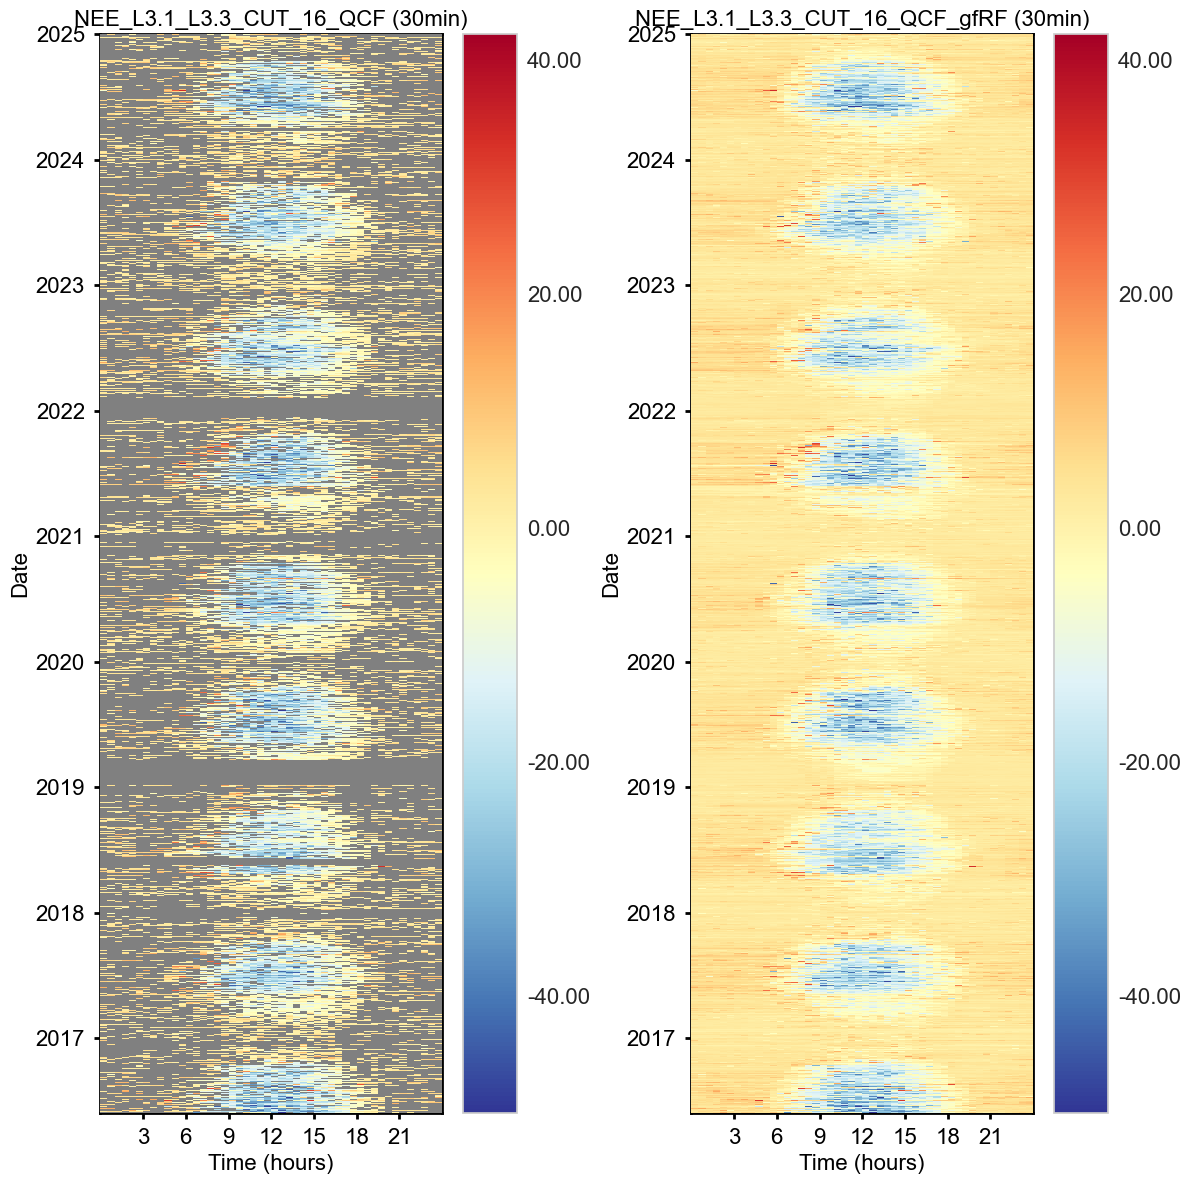

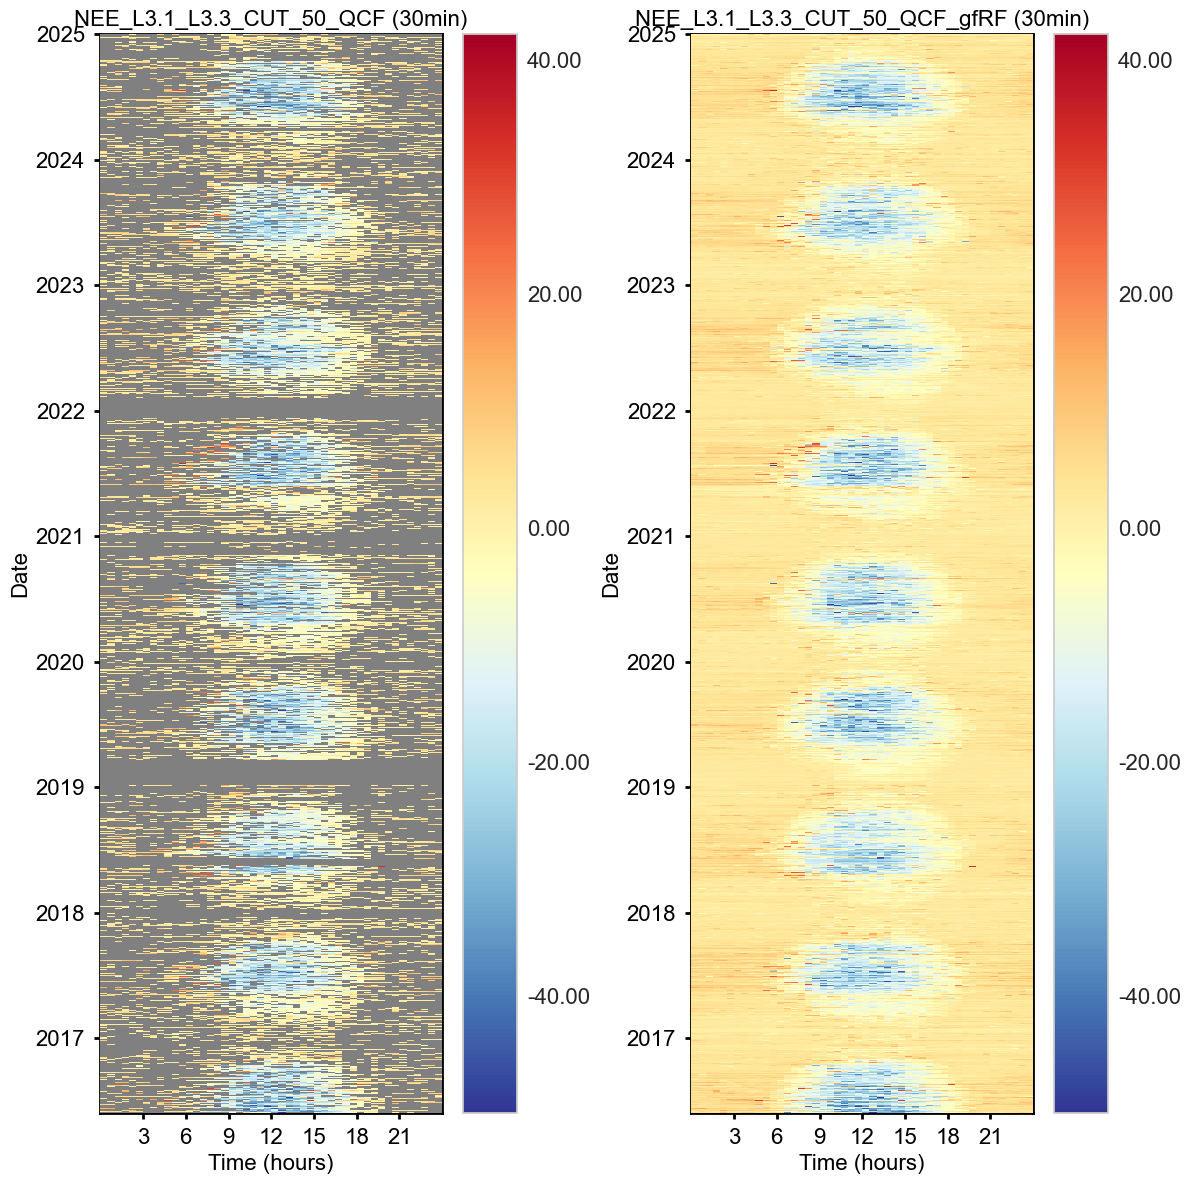

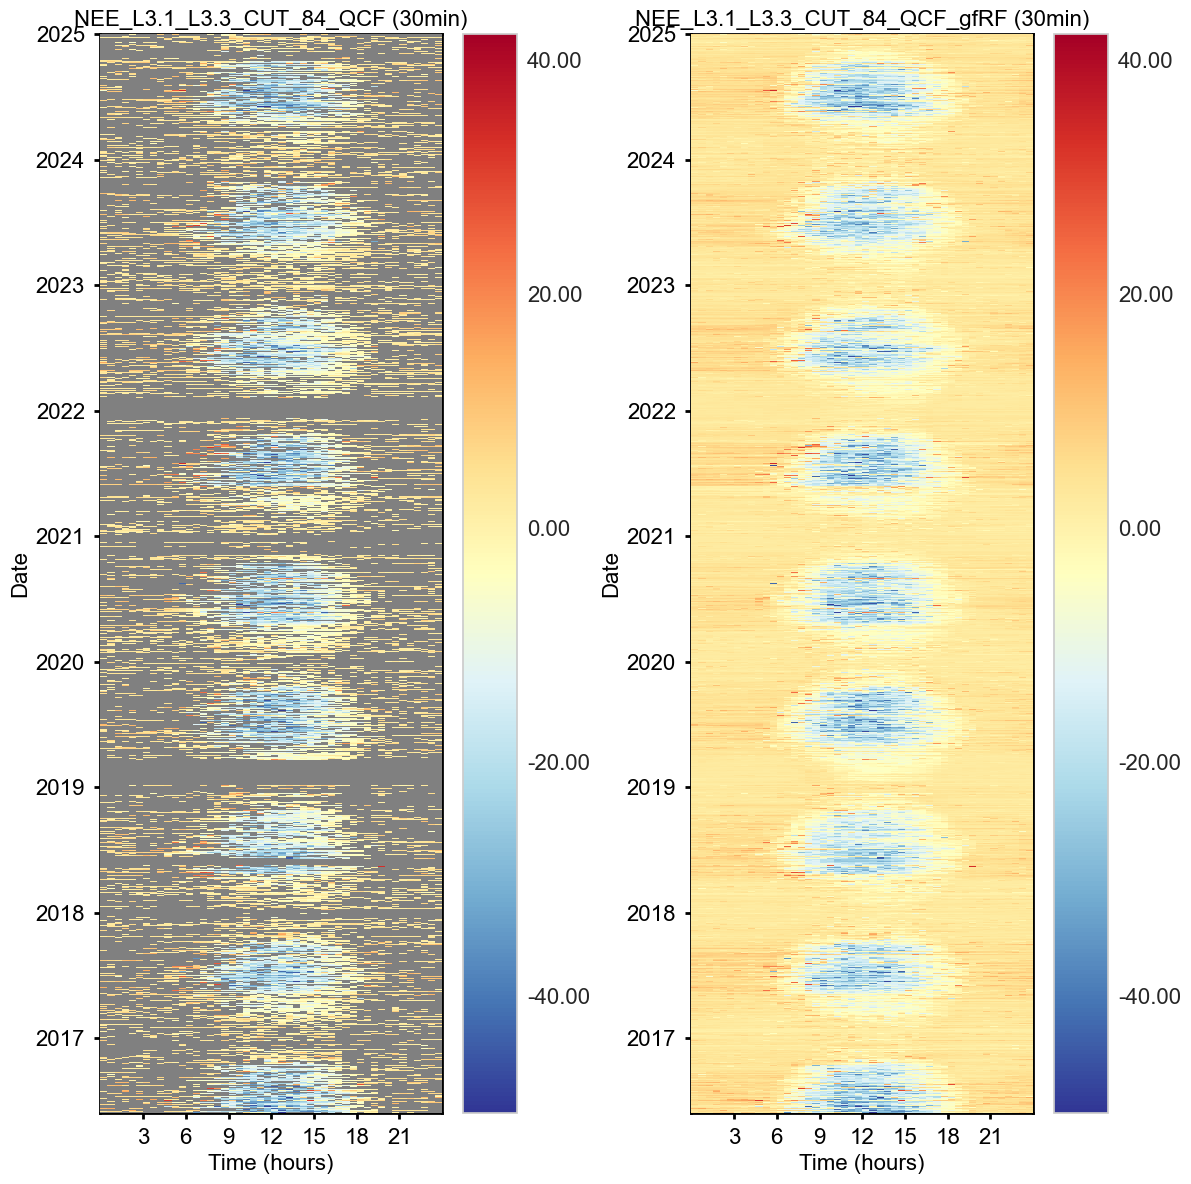

In [15]:
fpc.showplot_gapfilled_heatmap()

### Cumulatives per year

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\core\plotting\cumulative.py:145: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig.show()
F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\core\plotting\cumulative.py:145: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig.show()
F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\core\plotting\cumulative.py:145: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig.show()


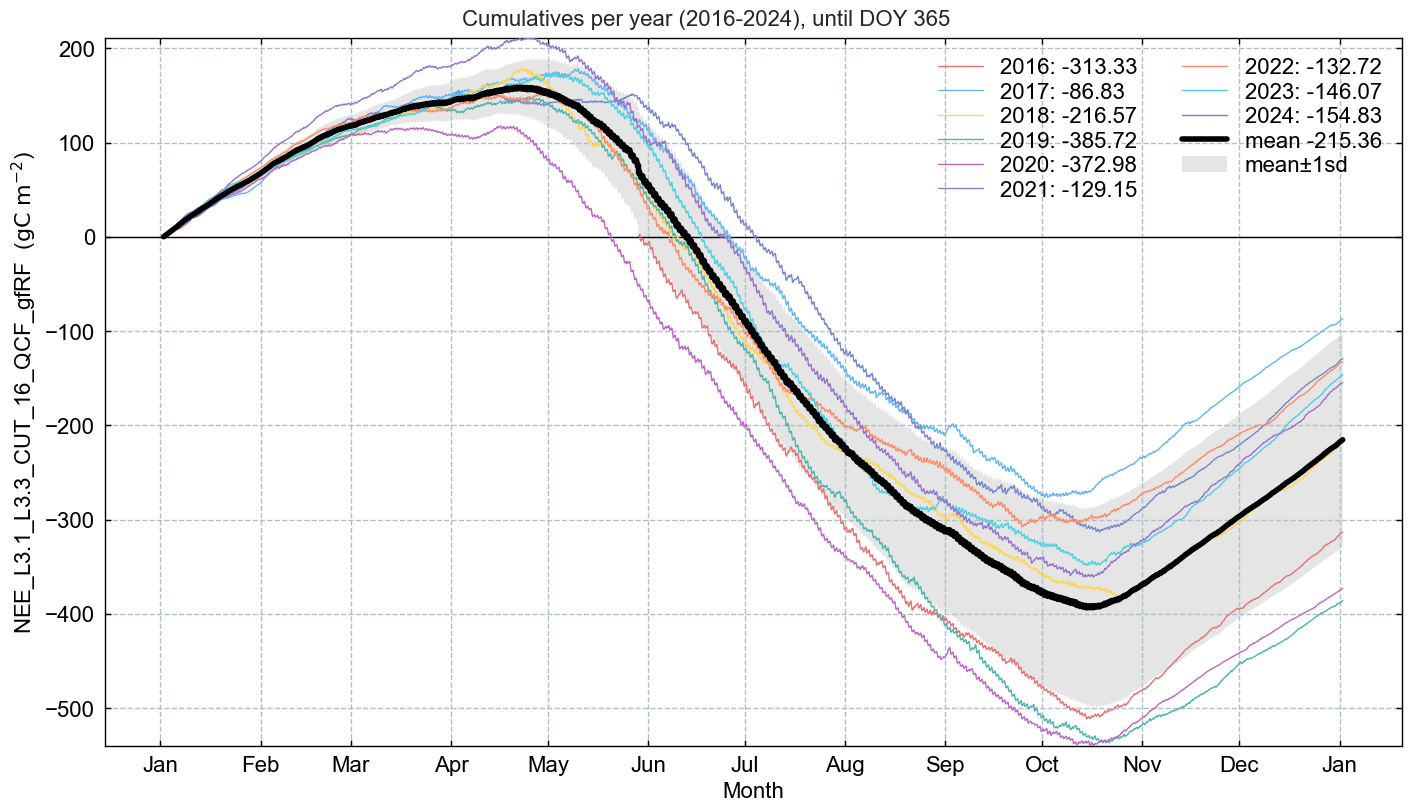

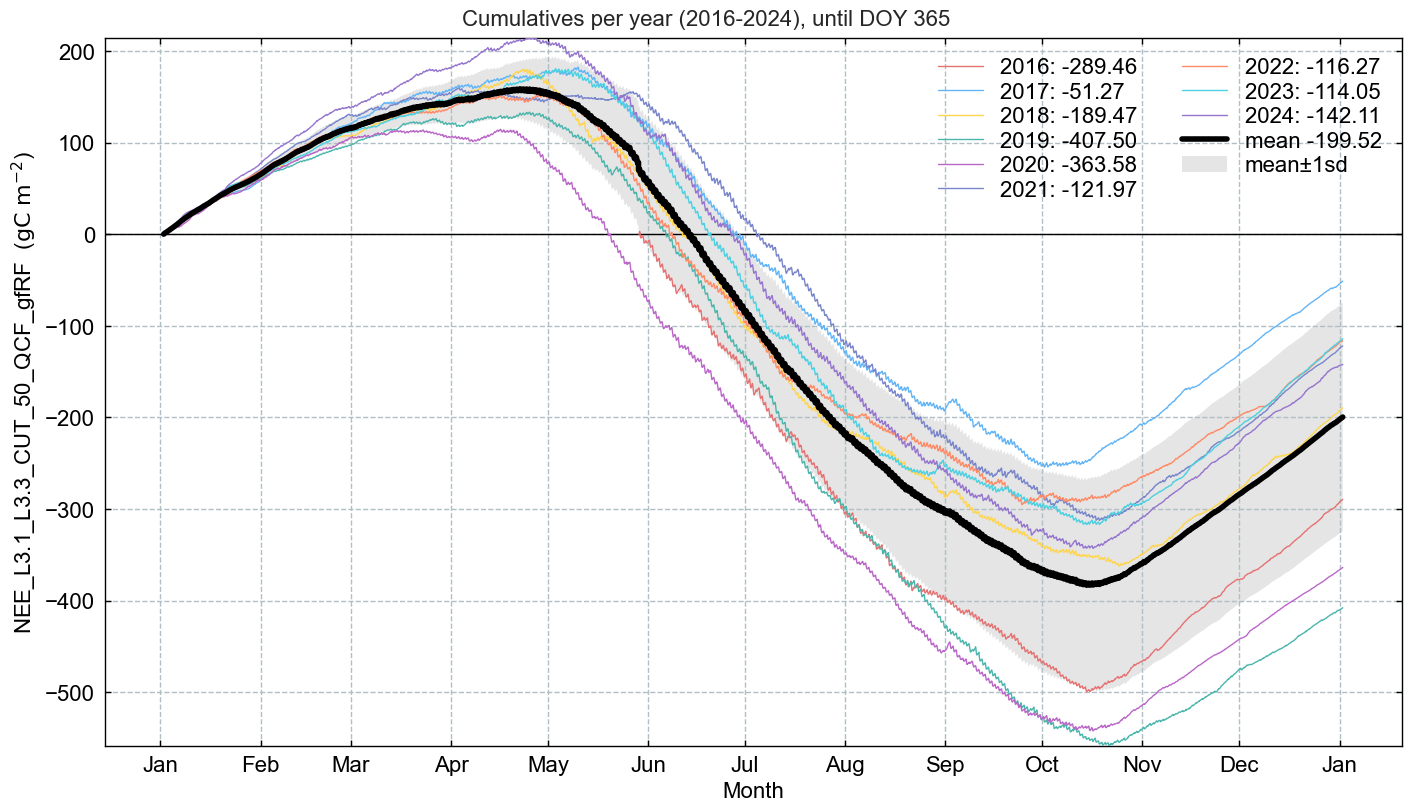

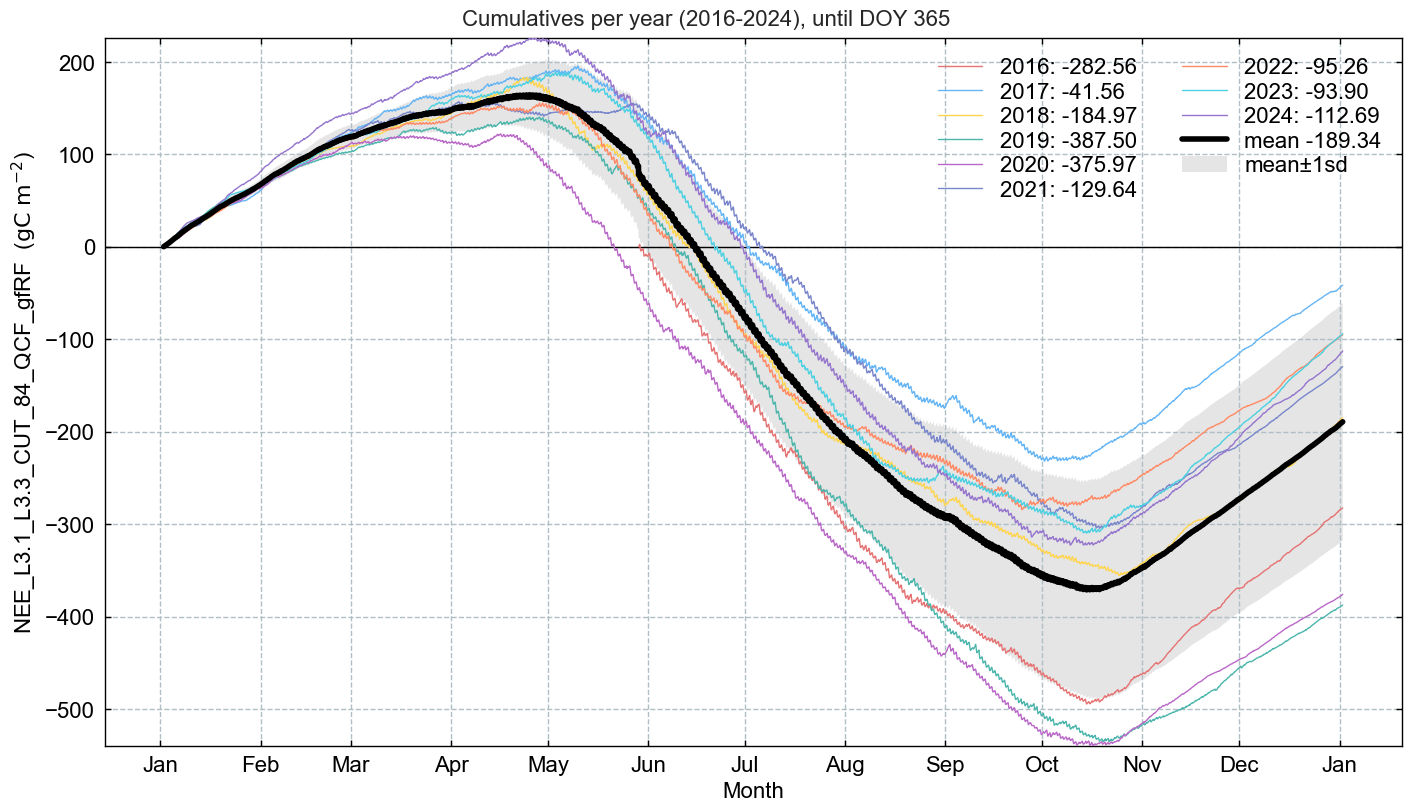

In [16]:
fpc.showplot_gapfilled_cumulative(gain=0.02161926, units=r'($\mathrm{gC\ m^{-2}}$)', per_year=True)

### Cumulative across all data 

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\core\plotting\cumulative.py:251: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig.show()


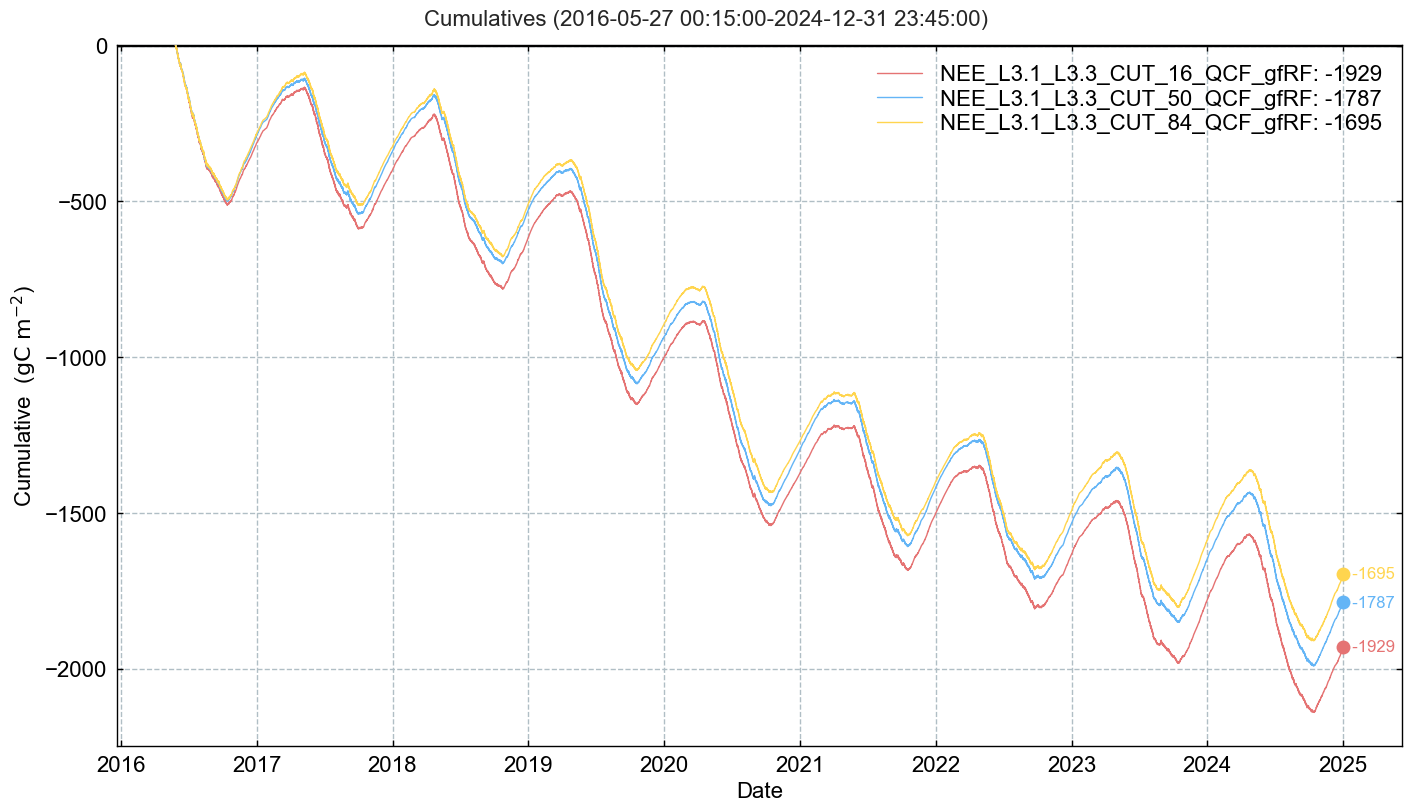

In [17]:
fpc.showplot_gapfilled_cumulative(gain=0.02161926, units=r'($\mathrm{gC\ m^{-2}}$)', per_year=False)

### ML Feature ranks per year (machine learning models only)

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\gapfilling\longterm.py:268: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(row.index, row.values, "o", marker=verts, ms=20,
F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\gapfilling\longterm.py:287: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


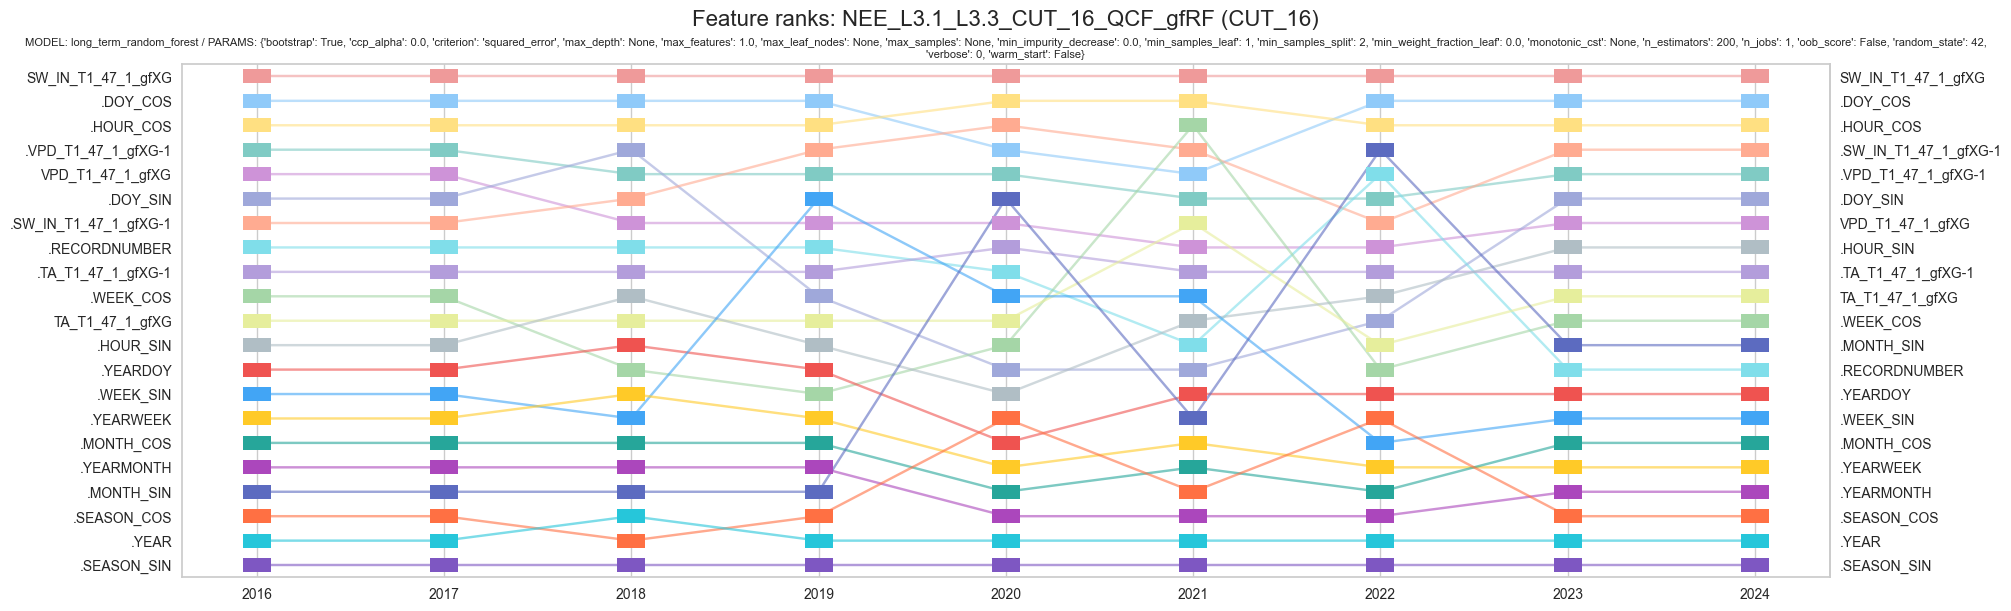

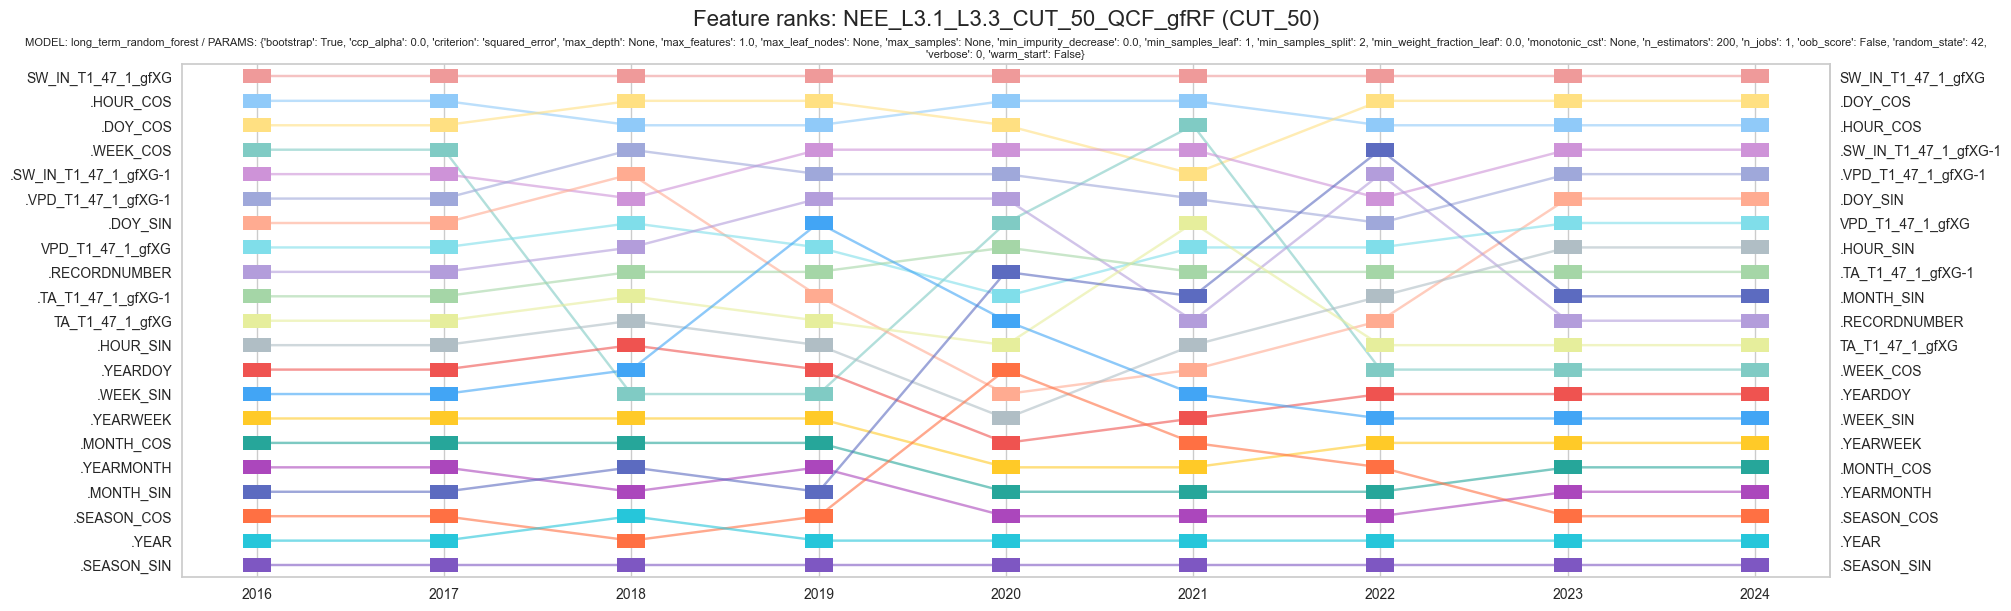

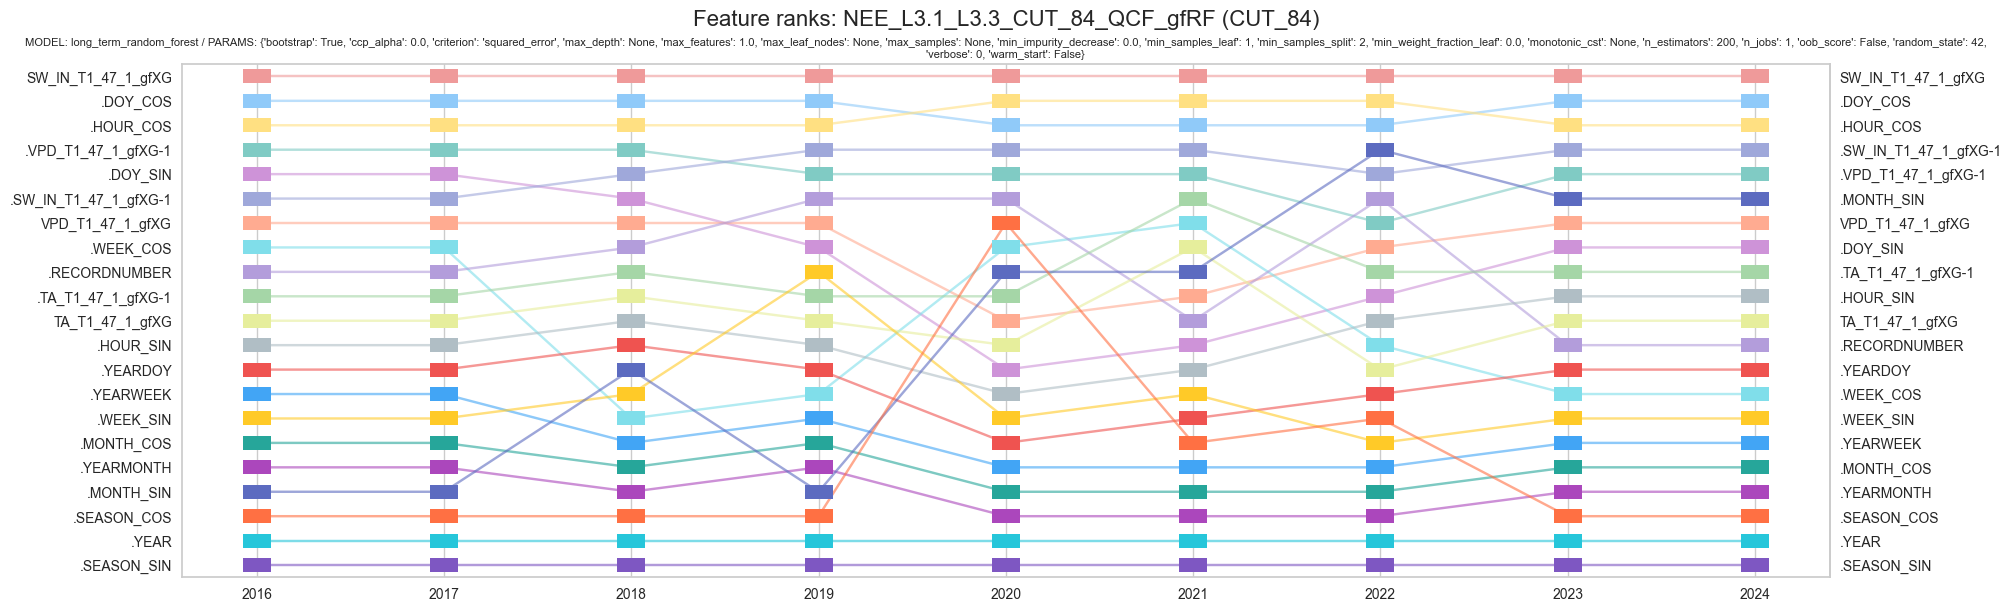

In [18]:
fpc.showplot_feature_ranks_per_year()

### MDS gap-filling qualities (MDS only, otherwise skipped)

In [19]:
fpc.showplot_mds_gapfilling_qualities()

</br>

</br>

<div style="
    height: 30px; /* Adjust height as desired */
    background: linear-gradient(135deg, #FF6B6B 0%, #FFE66D 100%); /* Warm gradient */
    background-image: 
        radial-gradient(circle at 100% 150%, #FF6B6B 0%, #FFE66D 100%),
        linear-gradient(to right, rgba(255,255,255,0.1) 1px, transparent 1px),
        linear-gradient(to bottom, rgba(255,255,255,0.1) 1px, transparent 1px);
    background-size: 100% 100%, 15px 15px, 15px 15px; /* Adjust pattern size */
    border-radius: 8px;
    box-shadow: 0 4px 8px rgba(0,0,0,0.1);
"></div>

# SAVE RESULTS TO FILE

- Save results to file for futher processing
- This can be useful if you want to use the data in another software, e.g. continuing post-processing using the library `ReddyProc` in `R` 
- `Parquet` format is recommended for large datasets

</br>

## Option 1: Save complete data (input data and results) to CSV (large and slow)

In [20]:
# results.to_csv("FluxProcessingChain_L4.1.csv")

</br>

## Option 2: Save input data and results to Parquet (small and fast)
- Needed if you want to continue post-processing in notebooks
- Can also be used in `R` with the `arrow` package

In [21]:
save_parquet(data=results, filename="02_FPC_IRGA72_NEE-QCF10-UST165084-L4.1-RF")

Saved file 02_FPC_IRGA72_NEE-QCF10-UST165084-L4.1-RF.parquet (3.094 seconds).


'02_FPC_IRGA72_NEE-QCF10-UST165084-L4.1-RF.parquet'

</br>

</br>

<div style="
    height: 30px; /* Adjust height as desired */
    background: linear-gradient(135deg, #FF6B6B 0%, #FFE66D 100%); /* Warm gradient */
    background-image: 
        radial-gradient(circle at 100% 150%, #FF6B6B 0%, #FFE66D 100%),
        linear-gradient(to right, rgba(255,255,255,0.1) 1px, transparent 1px),
        linear-gradient(to bottom, rgba(255,255,255,0.1) 1px, transparent 1px);
    background-size: 100% 100%, 15px 15px, 15px 15px; /* Adjust pattern size */
    border-radius: 8px;
    box-shadow: 0 4px 8px rgba(0,0,0,0.1);
"></div>

# ✅END OF NOTEBOOK

Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [22]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-12-02 11:49:52
